In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.load_data import load_data
from src.metrics import daily_sales, peak_hours, category_mix, promo_impact

# 👇 đảm bảo bạn đã đặt dataset ở:
# gs25-convenience-analytics/data/raw/

data = load_data("../data/raw")

transactions = data["transactions"]
lines = data["lines"]
stores = data["stores"]

transactions.head()

c:\Users\Admin\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,transaction_id,store_id,customer_id,datetime,day_of_week,hour,payment_method,promo_type,promo_applied,gross_amount_vnd,discount_amount_vnd,net_amount_vnd,gross_profit_vnd,basket_qty,unique_skus
0,T0000000001,S001,C010841,2025-12-01 18:47:51,0,18,card,none,False,632000,0,632000,220000,14,5
1,T0000000002,S001,C001167,2025-12-01 20:04:33,0,20,card,none,False,228000,0,228000,85000,6,3
2,T0000000003,S001,C008980,2025-12-01 18:50:29,0,18,e-wallet,none,True,176000,0,176000,62000,7,3
3,T0000000004,S001,C004463,2025-12-01 16:53:07,0,16,e-wallet,none,False,147000,0,147000,59000,6,3
4,T0000000005,S001,C006700,2025-12-01 21:29:45,0,21,cash,none,False,290000,0,290000,117000,11,5


In [2]:
print("transactions:", transactions.shape)
print("lines:", lines.shape)
print("stores:", stores.shape)

print("date range:", transactions["datetime"].min(), "->", transactions["datetime"].max())
print("promo share:", transactions["promo_applied"].mean() if "promo_applied" in transactions.columns else "n/a")

transactions: (313607, 15)
lines: (841367, 12)
stores: (25, 5)
date range: 2025-12-01 00:02:11 -> 2026-02-28 23:59:42
promo share: 0.12044692879942093


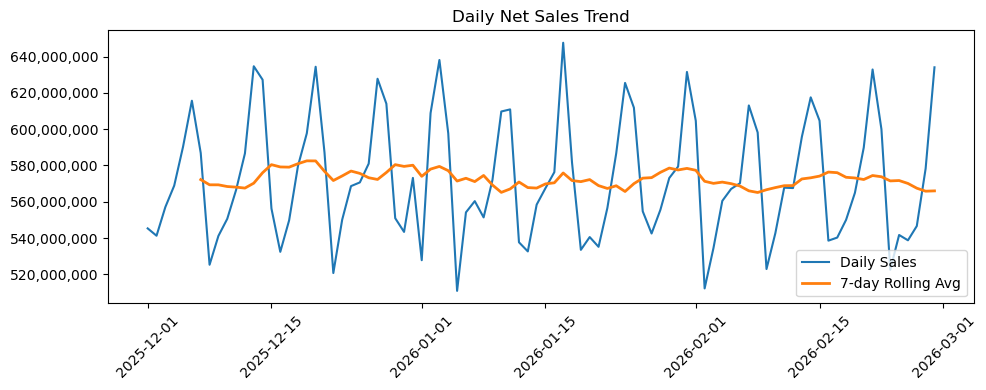

In [8]:
import matplotlib.ticker as mtick

daily = daily_sales(transactions)

plt.figure(figsize=(10,4))

plt.plot(daily["date"], daily["net_sales_vnd"], label="Daily Sales")
plt.plot(daily["date"], daily["net_sales_vnd"].rolling(7).mean(), 
         label="7-day Rolling Avg", linewidth=2)

plt.xticks(rotation=45)
plt.title("Daily Net Sales Trend")
plt.legend()

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

### Daily Trend Insights

- Clear weekly seasonality pattern.
- Higher sales on weekends compared to weekdays.
- No significant long-term growth or decline over the period.
- Stable base demand with periodic spikes.

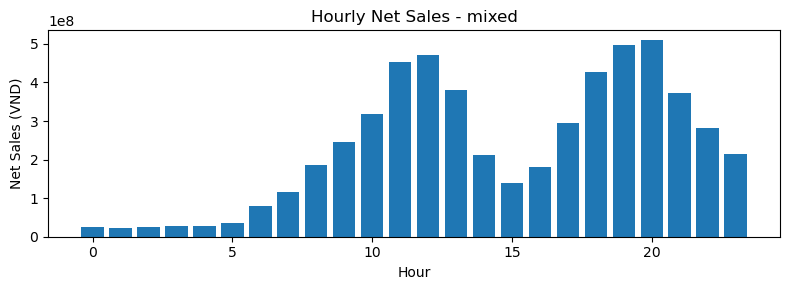

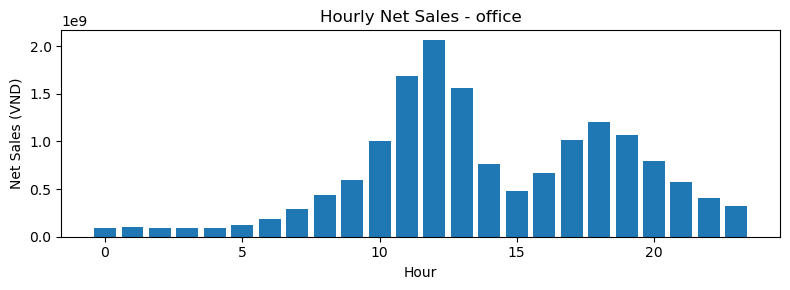

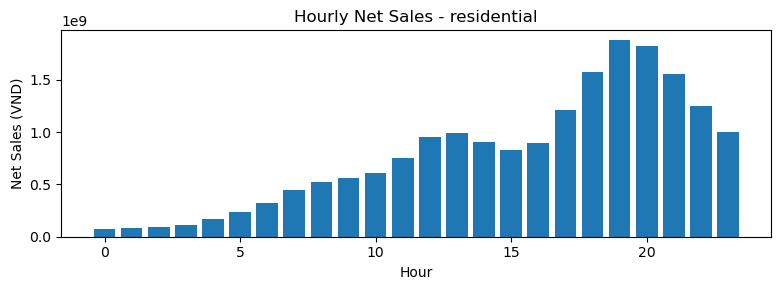

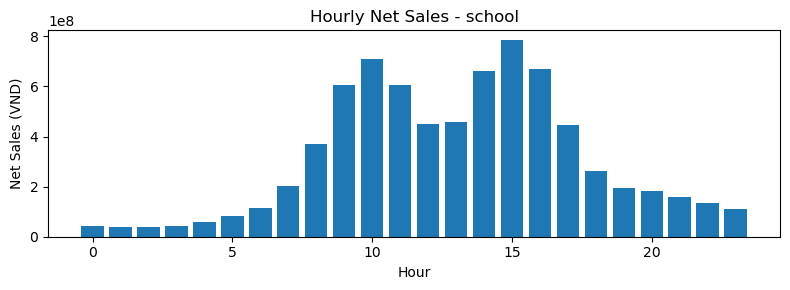

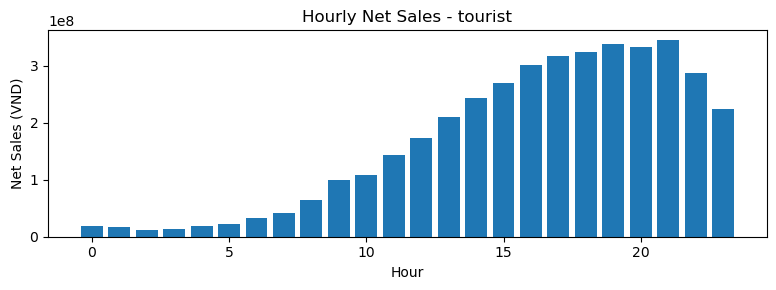

In [9]:
peak = peak_hours(transactions, stores)

for area in peak["area_type"].unique():
    tmp = peak[peak["area_type"] == area].sort_values("hour")
    plt.figure(figsize=(8,3))
    plt.bar(tmp["hour"], tmp["net_sales_vnd"])
    plt.title(f"Hourly Net Sales - {area}")
    plt.xlabel("Hour")
    plt.ylabel("Net Sales (VND)")
    plt.tight_layout()
    plt.show()

## Peak Hour Analysis – Business Interpretation

- Office stores show strong lunch-time spike (11–13h).
- Residential stores peak in the evening (19–21h).
- School areas concentrate demand during break hours.
- Tourist areas show stronger late-evening demand.
- Mixed areas exhibit dual-peak patterns.

### Recommendation:
- Optimize staffing by area_type.
- Deploy time-based promotions.
- Align product assortment with hourly demand pattern.

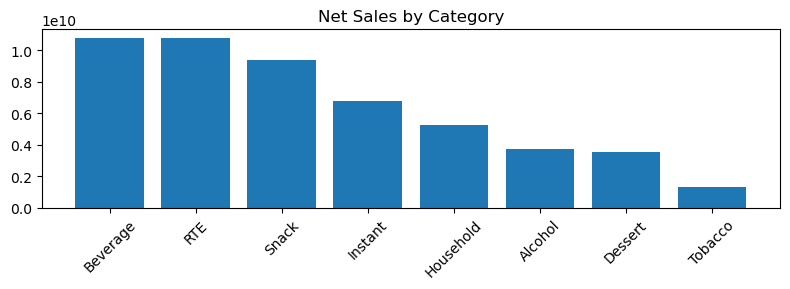

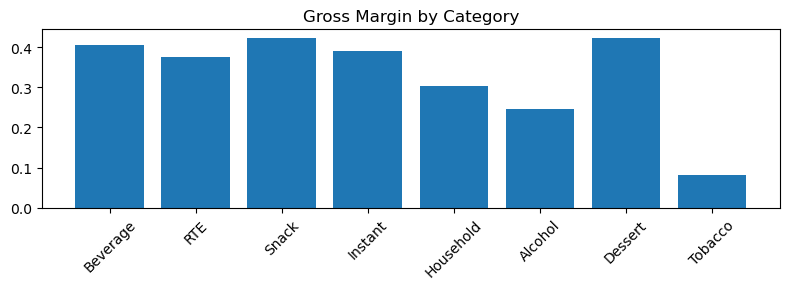

,category,net_sales_vnd,gross_profit_vnd,qty,gross_margin
1,Beverage,10797569250,4377233250,494081,0.405391
5,RTE,10795395870,4055900870,306123,0.375707
6,Snack,9363456920,3958007920,355512,0.422708
4,Instant,6762679470,2636114470,195324,0.389803
3,Household,5229077950,1590043950,99716,0.304077
0,Alcohol,3695133970,908596970,94652,0.245890
2,Dessert,3548039360,1503294360,124806,0.423697
7,Tobacco,1312349860,108123860,32070,0.082390


In [10]:
mix = category_mix(lines)

plt.figure(figsize=(8,3))
plt.bar(mix["category"], mix["net_sales_vnd"])
plt.xticks(rotation=45)
plt.title("Net Sales by Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
plt.bar(mix["category"], mix["gross_margin"])
plt.xticks(rotation=45)
plt.title("Gross Margin by Category")
plt.tight_layout()
plt.show()

mix

In [11]:
mix["profit_contribution_pct"] = mix["gross_profit_vnd"] / mix["gross_profit_vnd"].sum()
mix.sort_values("gross_profit_vnd", ascending=False)

,category,net_sales_vnd,gross_profit_vnd,qty,gross_margin,profit_contribution_pct
1,Beverage,10797569250,4377233250,494081,0.405391,0.228728
5,RTE,10795395870,4055900870,306123,0.375707,0.211937
6,Snack,9363456920,3958007920,355512,0.422708,0.206821
4,Instant,6762679470,2636114470,195324,0.389803,0.137747
3,Household,5229077950,1590043950,99716,0.304077,0.083086
2,Dessert,3548039360,1503294360,124806,0.423697,0.078553
0,Alcohol,3695133970,908596970,94652,0.245890,0.047478
7,Tobacco,1312349860,108123860,32070,0.082390,0.005650


## Category Mix Insights

- Beverage and RTE are key revenue drivers.
- Snack and Dessert provide the highest gross margin.
- Tobacco generates revenue but contributes minimal profit due to low margin.
- Recommend focusing promotion on high-margin scalable categories.
- Use RTE strategically as traffic driver rather than margin maximizer.

In [6]:
promo = promo_impact(transactions)
promo

,promo_type,transactions,avg_basket_qty,avg_net_sales_vnd,avg_profit_vnd,avg_margin
3,none,291800,5.427125,164712.230980,61433.564085,0.372975
1,combo_rte_bev,7058,5.450553,157167.024653,54227.098328,0.345028
0,coffee_discount,5992,5.410214,156344.667891,55584.487650,0.355525
4,snack_bogo,5653,5.421192,159193.037325,57240.799575,0.359568
2,late_night,3104,5.513853,159359.954897,55290.689433,0.346955


In [12]:
base = promo[promo["promo_type"]=="none"].iloc[0]

promo["sales_uplift_vs_none"] = promo["avg_net_sales_vnd"] / base["avg_net_sales_vnd"] - 1
promo["margin_change_vs_none"] = promo["avg_margin"] - base["avg_margin"]

promo.sort_values("sales_uplift_vs_none", ascending=False)

,promo_type,transactions,avg_basket_qty,avg_net_sales_vnd,avg_profit_vnd,avg_margin,basket_uplift_vs_none,sales_uplift_vs_none,margin_change_vs_none
3,none,291800,5.427125,164712.230980,61433.564085,0.372975,0.000000,0.000000,0.000000
2,late_night,3104,5.513853,159359.954897,55290.689433,0.346955,0.015981,-0.032495,-0.026020
4,snack_bogo,5653,5.421192,159193.037325,57240.799575,0.359568,-0.001093,-0.033508,-0.013407
1,combo_rte_bev,7058,5.450553,157167.024653,54227.098328,0.345028,0.004317,-0.045808,-0.027947
0,coffee_discount,5992,5.410214,156344.667891,55584.487650,0.355525,-0.003116,-0.050801,-0.017450


## Promotion Impact Analysis

- Promotions slightly increase basket size but reduce average margin.
- Net sales per transaction decline under most promotions.
- Current promotion strategy may erode profitability.

### Recommendation
- Focus on high-margin categories (Dessert, Snack) for promo bundles.
- Prioritize bundle-based promotions instead of direct discounts.
- Deploy time-based targeted promotions by area_type.

## Executive Summary

This analysis highlights three key drivers of performance:

1. **Demand is time- and location-sensitive**: peak hours differ significantly by store area type.
2. **Revenue and profit drivers differ**: Beverage and RTE drive revenue, while Snack and Dessert drive margin.
3. **Promotion design impacts profitability**: current promotions increase volume slightly but reduce margin.

Overall recommendation:
Optimize staffing by area type, prioritize high-margin product focus, and redesign promotions to protect gross profit.

## What I Would Analyze Next

If more data were available, I would further analyze:

1. Customer-level RFM segmentation (frequency & retention behavior).
2. Store-level performance benchmarking.
3. Price elasticity by category.
4. Promotion ROI at SKU level.
5. Private label vs national brand margin comparison.

This would enable more targeted merchandising and promotional strategies.